### Clone our [GitHub repository](https://github.com/zradj/roman-coins-deep-learning.git)

In [1]:
!rm -rf roman-coins-deep-learning

In [2]:
!git clone https://github.com/zradj/roman-coins-deep-learning.git

Cloning into 'roman-coins-deep-learning'...
remote: Enumerating objects: 67, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 67 (delta 31), reused 50 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (67/67), 1.36 MiB | 26.35 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [3]:
import sys
from pathlib import Path

# Add the cloned repository root to Python path so we can import the coin_classifier package
repo_path = Path('roman-coins-deep-learning').resolve()
if str(repo_path) not in sys.path:
    sys.path.insert(0, str(repo_path))

### The dataset can be downloaded from [authors' Google Drive](https://drive.google.com/file/d/1Bxcoesctd4xKvXMdgbLTCLjQkC7peQPY/view). The size of the dataset is approximately 8.7GB.

### Our pretrained model can be downloaded from [Google Drive](https://drive.google.com/file/d/1fd_7Sv0u2USUlhhmxbz3VH1052WT8vOo/view?usp=drive_link). The size of the model is approximately 99.6MB.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls drive/MyDrive/SaveGames/Data/

CoinsDataset.zip  RRC-60.zip


## Unzip CoinsDataset.zip

### Subtask:
Extract the contents of `CoinsDataset.zip` from its current location into a designated directory.


In [9]:
import os
import zipfile

# Define the paths
zip_file_path = 'drive/MyDrive/SaveGames/Data/CoinsDataset.zip'
extraction_path = '.'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")

'drive/MyDrive/SaveGames/Data/CoinsDataset.zip' unzipped to '.' successfully.


# Exploratory Data Analysis (EDA)

In this project, we will use the `Roman Republican Coin Dataset`, specifically its _main dataset_ called `RRCD-Main`, that consists of approximately 18,000 different coin images from the Roman Republican era. The images are labeled with 100 different classes that represent different reverse motifs, such as "quadriga, griffin, elephant, and many more". More details on the dataset can be found in the paper where it was introduced [(Anwar et al., 2020)](https://arxiv.org/pdf/1908.09428).

## Structure

The dataset consists of the main folder, `images`, and three auxiliary files: `images.txt`, `labels.txt`, and `split.txt`. The main folder contains the image files distributed into numbered folders based on their label classes.

`images.txt` maps the image names to a sequence of integers starting from 1.

`labels.txt` maps each image number to the corresponding label.

`split.txt` splits the dataset into train and test sets.


In [10]:
import os
from IPython.display import display, HTML

def build_tree(root, max_files=5, indent='', is_last=True, is_first=True):
    lines = []
    name = os.path.basename(root) or root
    connector = '└── ' if is_last else '├── '
    lines.append(indent + (connector if indent else '') + f'<b>{name}/</b>')
    indent += '    ' if is_last else '│   '

    try:
        entries = sorted(os.listdir(root))
    except PermissionError:
        lines.append(indent + '└── [permission denied]')
        return lines

    dirs  = [e for e in entries if os.path.isdir(os.path.join(root, e))]
    files = [e for e in entries if os.path.isfile(os.path.join(root, e))]

    for i, d in enumerate(dirs):
        is_last_entry = (i == len(dirs) - 1) and not files
        lines += build_tree(os.path.join(root, d), max_files, indent, is_last_entry, is_first=False)

    if len(files) <= max_files or is_first:
        for i, f in enumerate(files):
            connector = '└── ' if i == len(files) - 1 else '├── '
            lines.append(indent + connector + f)
    else:
        for f in files[:max_files]:
            lines.append(indent + '└── ' + f)
        lines.append(indent + f'└── <i>... ({len(files) - max_files:,} files)</i>')

    return lines


lines = build_tree('CoinsDataset/', max_files=0)

display(HTML(f"""
<pre style="font-size: 11px; line-height: 1.2; font-family: monospace;">
{'<br>'.join(lines)}
</pre>
"""))

## Dimensions

The dimensions of images vary from 99x99 to 2260x2260 pixels (all images are in the shape of a square or are very close to it). Thus, we had to resize the images to provide a uniform image format for the model. We mainly considered three options: 64x64 (minimize the computation cost and not magnify any images), 128x128 (balance the computation cost and magnify about 50 images), and 256x256 (maximize the computation cost and magnify about 1000 images). We decided to continue with 256x256 since it preserves fine coin details (inscriptions, portraits, symbols) necessary for distinguishing visually similar classes, at the cost of higher computation.

**Phase 2 update:** The input resolution is now a configurable parameter (`image_size` in `config.py`). Both the dataset transforms and model architecture adapt automatically. After experimentation, 256x256 was selected as the final resolution — it recovers fine details lost at 64x64, particularly for confusable classes like Class 15 and Class 60. To manage GPU memory at this resolution, `patch_size` was increased to 8 (yielding 1024 patches) and `batch_size` reduced to 32.

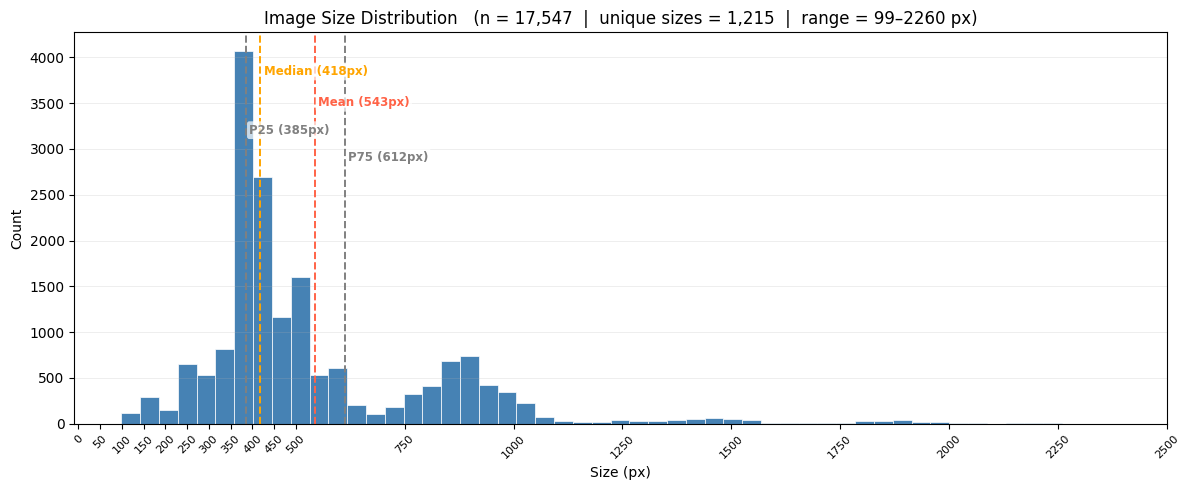

In [ ]:
from coin_classifier import plot_image_size_distribution

plot_image_size_distribution(base_path='CoinsDataset')

## Demonstration

The following code demonstrates five sample images from the dataset along with their labels:

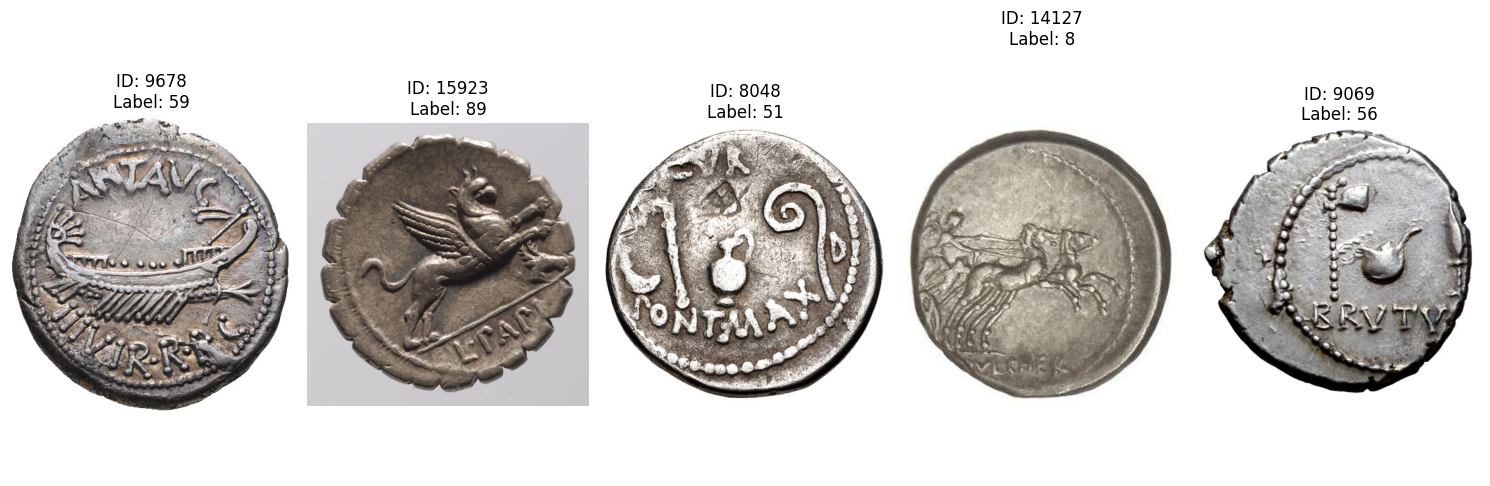

In [35]:
from coin_classifier import show_sample_images

show_sample_images(base_path='CoinsDataset', n=5)

## Create Stratified Train/Test Split

Generate the split.txt file with **stratified sampling** to ensure equal class distribution across train and test sets. Each coin class (label) will have the same proportion in both training and testing splits.

In [12]:
from coin_classifier import create_stratified_split

train_count, test_count = create_stratified_split(
    base_path='CoinsDataset',
    test_ratio=0.2,
    random_seed=42
)

print(f"\nTraining set: {train_count} images")
print(f"Test set: {test_count} images")

Stratified split created: 14075 train, 3472 test

Training set: 14075 images
Test set: 3472 images


# Start training KAN-Mixer

**Phase 2 update:** Training now uses **data augmentation** to close the train-test generalisation gap observed in Phase 1 (99.4% train vs 83.4% test). The augmentation pipeline (defined in `dataset.py`) applies random horizontal flips, rotation (±15°), and colour jitter (brightness/contrast ±0.2, saturation ±0.1) to the training set only. The test set uses deterministic transforms for reproducible evaluation.

**Results:** After 20 epochs at 256x256 resolution, the model achieves **94.14% train accuracy** and **87.24% test accuracy** — the train-test gap is reduced to ~7% (down from ~16% in Phase 1), confirming that augmentation effectively regularises the model.

## DataLoader Hyperparameters

---

`batch_size = 32` - Batch size for training/testing

**Explanation:** Reduced from 128 to 32 to accommodate the larger 256x256 input resolution and the memory-intensive B-spline computations in KAN-Mixer layers. With patch_size=8, each image produces 1024 patches, requiring significantly more GPU memory per sample.

---

`num_workers = 4` - Number of worker processes for data loading

**Explanation:** Set to 4 for multiprocessing and as a result faster data loading

---

`shuffle_train = True` - Shuffle training data

**Explanation:** Randomizes training order each epoch to:
- Prevent overfitting to data order
- Improve generalization
- Ensure balanced mini-batches

---

`shuffle_test = False` - Don't shuffle test data

**Explanation:** Keep test data in consistent order for:
- Reproducible evaluation results
- Easier debugging and analysis
- Fair comparison across runs

---

**Phase 2 update:** Training data now goes through an augmentation pipeline (`augment=True` in `get_transforms()`) before being fed into the DataLoader. Augmented transforms include random horizontal flip, rotation (±15°), and colour jitter. Test data is **not** augmented to ensure fair and reproducible evaluation.

In [ ]:
import torch
from coin_classifier import get_coin_config, train_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = get_coin_config()

print(f"Using device: {device}")

## Hyperparameters for `KAN-Mixer`

---

### Input Configuration

---

`"in_channels": 3` - RGB images (3 color channels)

**Explanation:** Coins have subtle color variations (patina, metal types) that help distinguish between different coin types and periods.

---

`"image_size": 256` - Resized to 256x256 pixels

**Explanation:** Higher resolution preserves fine coin details (inscriptions, portraits, symbols) critical for distinguishing visually similar classes. At 64x64 many distinguishing features between confusable classes (e.g. Class 15 vs Class 60) were lost.

---

`"patch_size": 8` - 8x8 pixel patches

**Explanation:** With image_size=256, patch_size=8 yields 1024 patches per image. This balances spatial granularity with GPU memory constraints — smaller patches (e.g. 4) would produce 4096 patches and cause OOM errors on most GPUs.

---

### Model Architecture

---

`"num_classes": 100` - 100 different coin types in the dataset

**Explanation:** Fixed by dataset - each class represents a unique Roman coin type with distinct historical and visual characteristics.

---

`"channel_dim": 256` - Increased capacity for complex coin features

**Explanation:** Coins have intricate details (text, portraits, symbols). 256 dimensions provide sufficient capacity to encode fine-grained visual differences between similar coin types.

---

`"token_dim": 128` - Increased token dimension for spatial relationships

**Explanation:** Coins have spatial relationships between elements (portrait position, text layout, symbols). 128 dims capture these positional and relational features effectively.

---

`"depth": 6` - Deeper model for better feature extraction

**Explanation:** 6 layers allow hierarchical learning:
- Early layers: edges, textures, basic shapes
- Middle layers: coin elements (portraits, inscriptions)
- Output layer: complete coin type identification

---

### Training Configuration

---

`"learning_rate": 1e-3` - Lower learning rate for fine-grained classification

**Explanation:** Conservative learning rate prevents overshooting optima in the complex 100-class space. Allows model to learn subtle inter-class differences without unstable training.

---

`"batch_size": 32` - Reduced batch size for high-resolution training

**Explanation:** With 256x256 images and 1024 patches per image, the B-spline computations in KAN layers require substantial GPU memory. Batch size 32 fits within H100 GPU memory on Colab Pro.

---

`"num_epochs": 20` - Train for 20 epochs

**Explanation:** Model converged around epoch 16–17 (best test accuracy 87.50% at epoch 17), with diminishing returns after that. 20 epochs allows convergence verification without excessive training time.

---

### Output Configuration

---

`"model_folder": "weights_coins"` - Directory for saving model checkpoints

---

`"model_basename": "kan_mixer_coins_"` - Prefix for model checkpoint files

---

`"resume_epoch": None` - Epoch checkpoint to resume from (None = train from scratch)

**Explanation:** Set to an integer (e.g. 13) to resume training from that checkpoint. Set to None to start fresh.

---

**Phase 2 update:** All hyperparameters are now centralised in `config.py` (`get_coin_config()`), making them easy to modify for resolution and augmentation experiments without editing the notebook.

In [ ]:
print("Configuration for Roman Coin Classification:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20}: {value}")

In [ ]:
model, train_losses, train_accuracies, test_accuracies = train_model(
    base_path="CoinsDataset",
    config=config,
    augment=True,
    device=device,
)

print("Training completed!")

## Evaluation

To evaluate model's perfomance, choose the model source:

- `USE_EXISTING_MODEL`: set to False if model is loaded from checkpoint on disk. Otherwise, set to True
- `MODEL_PATH`: if `USE_EXISTING_MODEL` is set to False, set the path to checkpoint from which model will be loaded

In [19]:
# Configuration: Choose model source
USE_EXISTING_MODEL = True # Set to False to load from file
MODEL_PATH = ""  # Update this path when USE_EXISTING_MODEL = False

In [ ]:
from torch.utils.data import DataLoader
from coin_classifier import load_model, evaluate_comprehensive, print_metrics, CoinsDataset, get_transforms

if not USE_EXISTING_MODEL:
    print(f"Loading model from file: {MODEL_PATH}")
    if 'device' not in dir():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model(MODEL_PATH, device)
else:
    print("Using existing model variable")

test_transform = get_transforms(config["image_size"], augment=False)
test_dataset = CoinsDataset("CoinsDataset", split="test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=4)

final_metrics, predictions, true_labels, probabilities = evaluate_comprehensive(
    model, test_loader, device, num_classes=config["num_classes"]
)

# Insights

## 1. F1 Score Comparison
Macro, Micro, and Weighted F1 scores are closely clustered (**0.860, 0.872, 0.872**). This tight grouping suggests the classes are relatively **balanced in size** — if there were heavy class imbalance, Macro and Weighted would diverge significantly. An overall F1 of ~0.87 is strong for a fine-grained visual classification task like ancient coins.

---

## 2. Top-K Accuracy

| K | Accuracy |
|---|---|
| Top-1 | 0.872 |
| Top-5 | 0.968 |
| Top-10 | 0.982 |

The jump from Top-1 to Top-5 is **+9.6%**, meaning the correct class is frequently in the model's top candidates but not always ranked first. This suggests the model is **confusing visually similar coin types** — the right answer is "almost there" rather than completely wrong.

---

## 3. Per-Class F1 Distribution
The distribution is **strongly left-skewed** — most classes cluster between 0.8–1.0, but a tail extends down toward 0. The macro average of **0.860** is pulled down by a handful of poorly predicted classes. The majority of classes are actually performing better than the average suggests.

---

## 4. Best & Worst Classes

- **Worst performers** *(red)*: Class 15 (~0.1 F1) and Class 60 (~0.45 F1) remain the hardest to classify. Class 15 is almost entirely misclassified as Class 60 (17 out of 22 predictions). Class 60 is split evenly between correct and confused with Class 15 (14/14).
- **Best performers** *(green)*: Classes 23, 40, 96, 85, 46, 69 etc. all score **0.95–1.0**, suggesting these coin types have distinctive, consistently captured visual features.

---

## 5. Training Dynamics

- **Training loss** decreased steadily from ~0.38 to ~0.23 over epochs 14–20.
- **Train accuracy** reached 94.14%, **test accuracy** peaked at 87.50% (epoch 17) with final test accuracy at 87.24%.
- The train-test gap (~7%) indicates mild overfitting, significantly improved from Phase 1 (99.4% vs 83.4% gap of ~16%) thanks to data augmentation.

---

## Key Takeaway
The model achieves **87.24% test accuracy** with the 256x256 resolution and data augmentation — a substantial improvement over Phase 1's 83.4% at 64x64. The remaining accuracy gap is concentrated in a few problem classes (particularly the Class 15/60 confusion pair). Phase 2's higher resolution helped raise Class 60 from ~0.05 to ~0.45 F1, but Class 15 remains problematic due to bidirectional confusion with Class 60.

Accuracy:           0.8724 (87.24%)
F1 Score (Macro):   0.8600
F1 Score (Micro):   0.8724
F1 Score (Weighted):0.8724
Precision (Macro):  0.8647
Recall (Macro):     0.8619
Top-5 Accuracy:     0.9680 (96.80%)
Top-10 Accuracy:    0.9816 (98.16%)


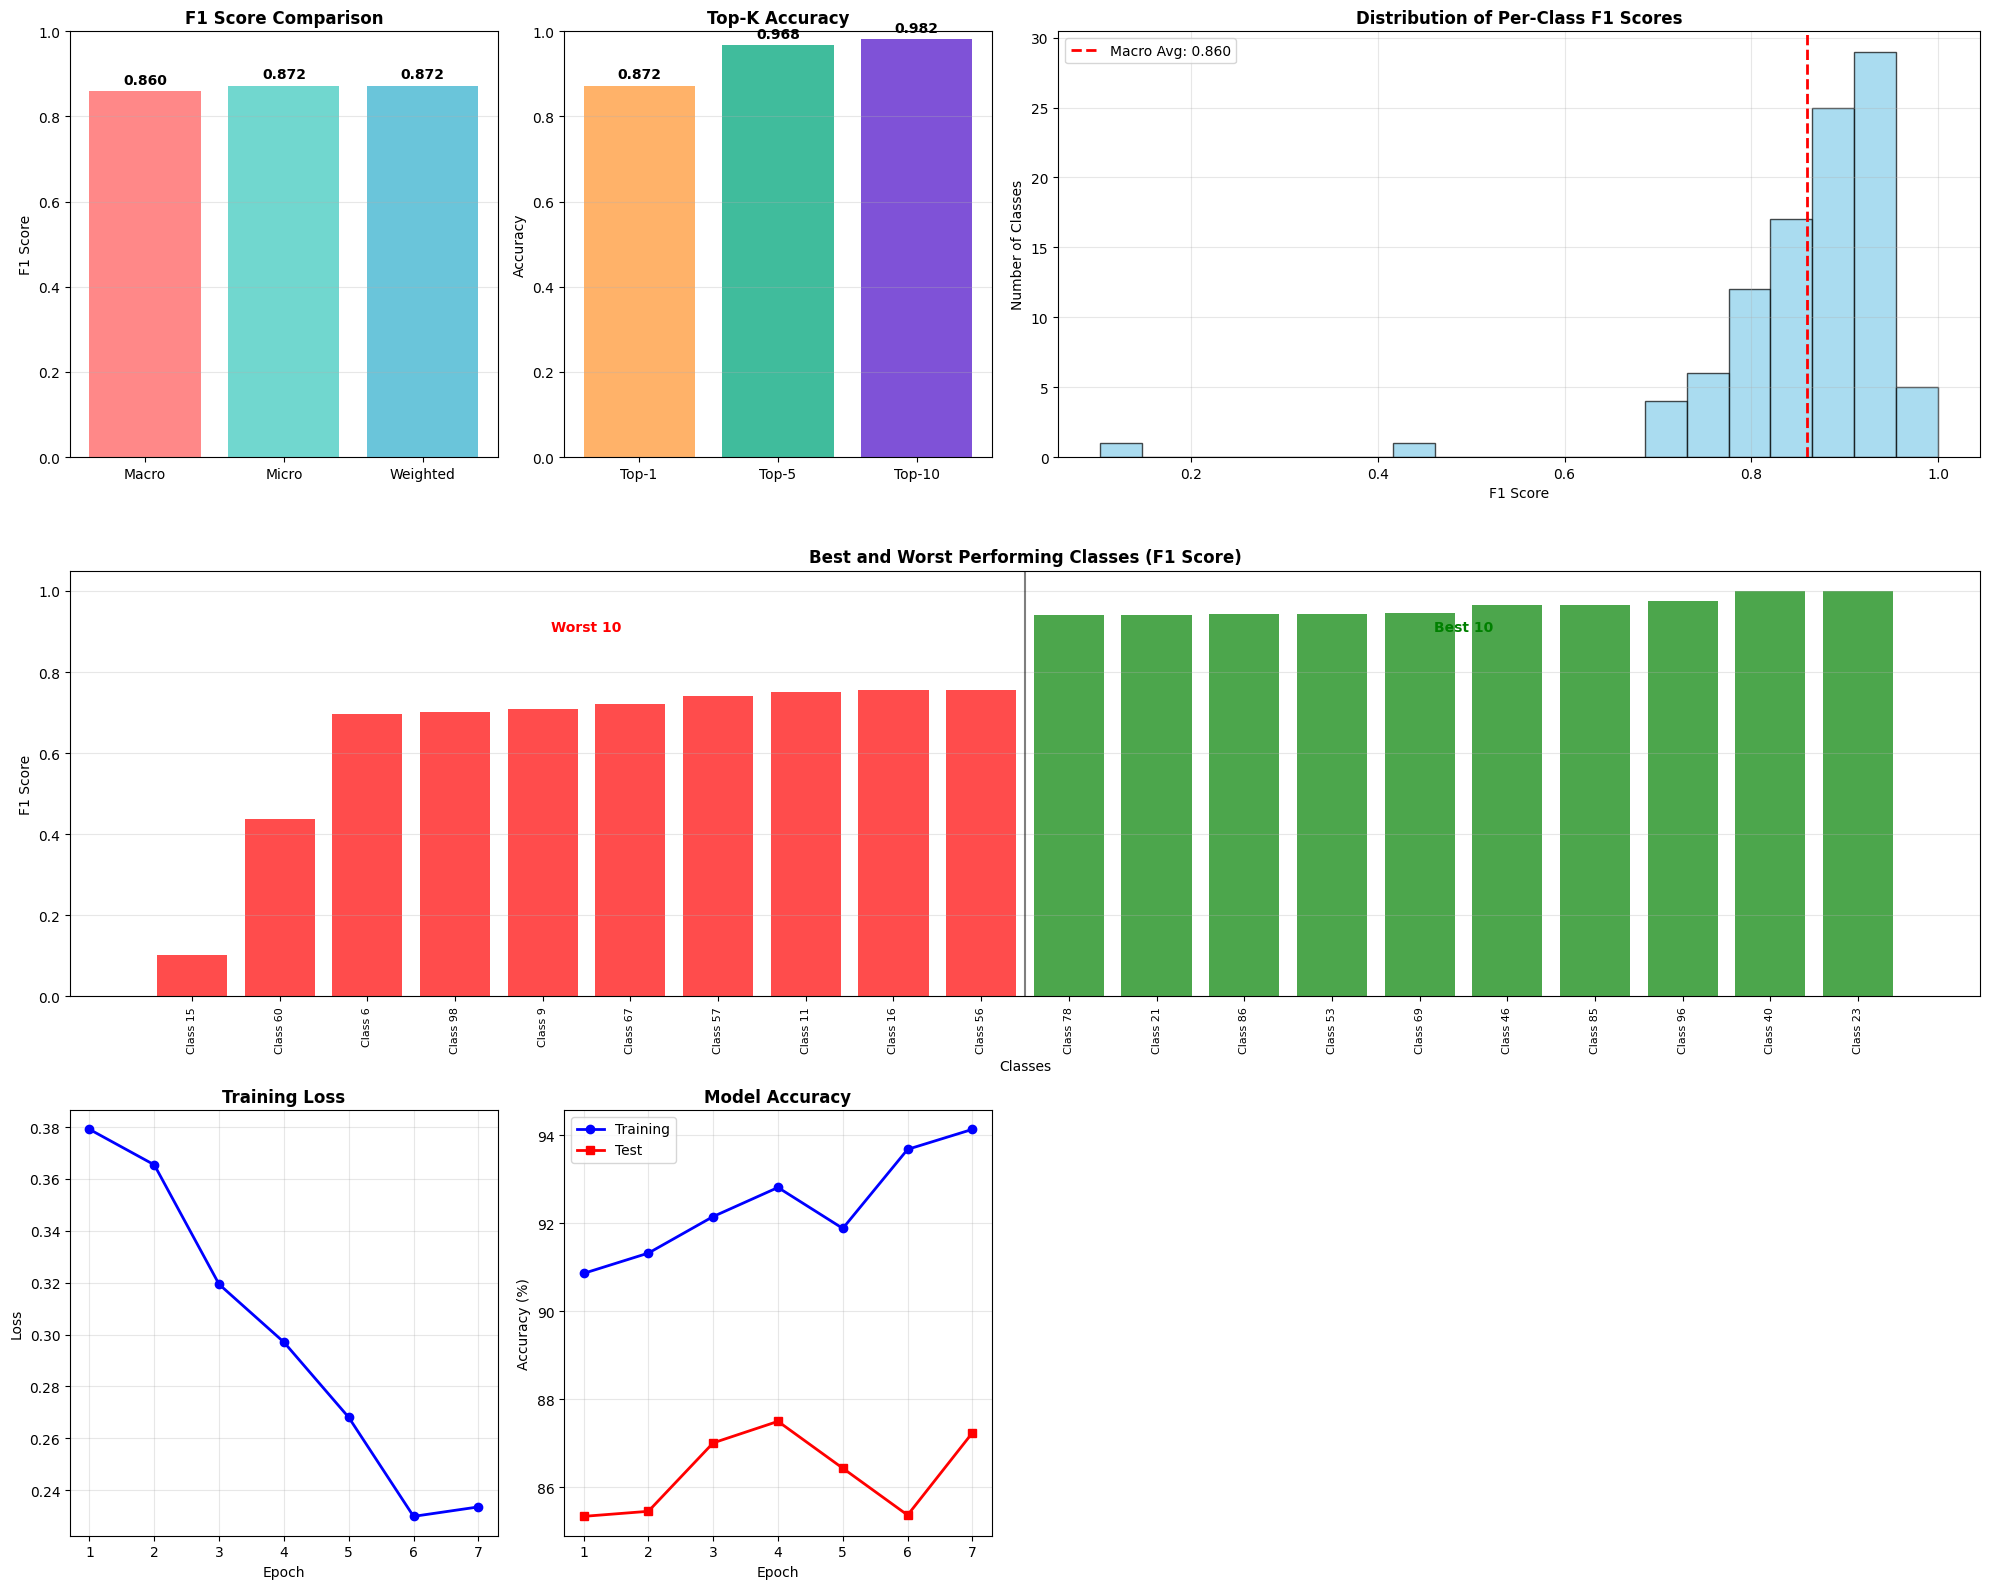

In [21]:
from coin_classifier import print_metrics, plot_results

print_metrics(final_metrics)

plot_results(
    final_metrics,
    train_losses=train_losses if USE_EXISTING_MODEL else None,
    train_accuracies=train_accuracies if USE_EXISTING_MODEL else None,
    test_accuracies=test_accuracies if USE_EXISTING_MODEL else None,
)

## Worst performing classes — investigation

Looking at their samples, it is hard to detect any differences even for the human eye. The only difference is that **Class 15** coins are more detailed than **Class 60**, possibly due to improvements in coin production tools of that era.

The confusion matrix confirms strong bidirectional confusion:
- **Class 15** (label index 14): 17 out of 22 samples were misclassified as Class 60, only 2 correct → F1 ≈ 0.1
- **Class 60** (label index 59): 14 correct, but 14 were misclassified as Class 15 → F1 ≈ 0.45

### Phase 2 improvements — results

1. **Higher resolution (256x256)** — increased from 64x64 to 256x256. This improved Class 60's F1 from ~0.05 (Phase 1) to ~0.45, confirming that finer details help disambiguate these classes. However, Class 15 remains nearly unresolvable (F1 ≈ 0.1).
2. **Data augmentation** — random flips, rotation, and colour jitter helped reduce overall overfitting (train-test gap from ~16% to ~7%) but did not resolve the Class 15/60 confusion.
3. **Next step** — consult domain experts to confirm whether Classes 15 and 60 are genuinely distinct reverse motifs or represent a labelling ambiguity in the original RRCD-Main dataset. If distinct, targeted augmentation or a dedicated auxiliary loss for this pair may help.


Class 15



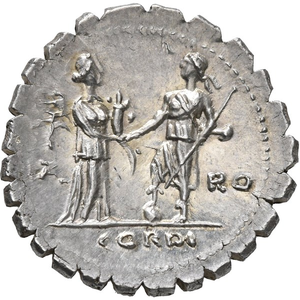


Class 60



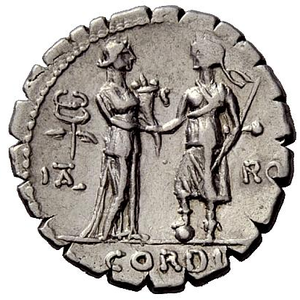

In [36]:
from IPython.display import display
from PIL import Image

print("\nClass 15\n")
# Open an image file
img = Image.open('CoinsDataset/images/15/4458931.png')

# Define the new size as a tuple (width, height)
new_size = (300, 300)

# Resize the image and get a new Image object
resized_img = img.resize(new_size, Image.LANCZOS)
display(resized_img)
print("\nClass 60\n")
# Open an image file
img = Image.open('CoinsDataset/images/60/759149.png')
resized_img = img.resize(new_size, Image.LANCZOS)
display(resized_img)

In [37]:
from coin_classifier import print_confused_classes

In [38]:
print_confused_classes(final_metrics['confusion_matrix'], label_index=14)

14     2
59    17
66     1
73     1
82     1
dtype: int64


In [39]:
print_confused_classes(final_metrics['confusion_matrix'], label_index=59)

14    14
59    14
73     1
82     1
98     1
dtype: int64
